![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

W zeszycie przedstawiono podstawy statystyki opisowej dla analizy dwóch zmiennych losowych i regresji.

In [1]:
import numpy as np
import scipy as sp
import scipy.stats as ssp
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [2]:
N = 500
X = ssp.norm(5,2)
noise = ssp.norm(0,0.5)

x = X.rvs(N)
y = x + noise.rvs(N)

**Wykres rozrzutu**

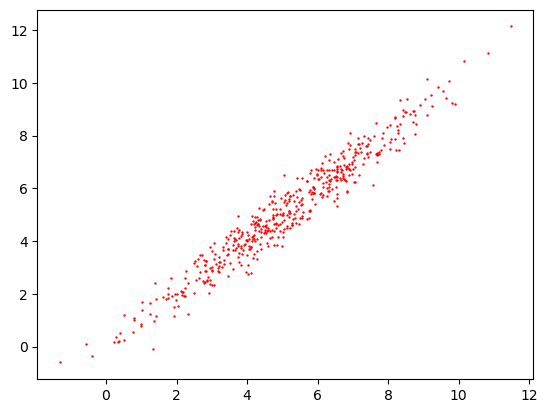

In [3]:
plt.scatter(x,y,marker="o",s=0.5,c="red",label="data")
pass

**Regresja liniowa zbioru danych**

LinregressResult(slope=0.9932447063611526, intercept=0.058694555694281725, rvalue=0.9728264226847954, pvalue=1.39544e-318, stderr=0.010593124478994478, intercept_stderr=0.058382063252664956)


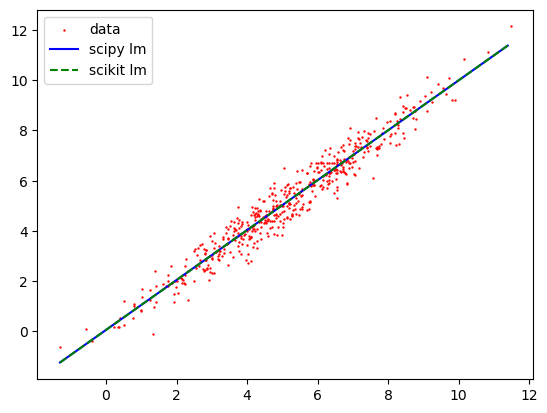

In [4]:
scipy_lm = ssp.linregress(x,y)
print(scipy_lm)
a= scipy_lm.slope
b = scipy_lm.intercept
xp = np.arange(min(x),max(x),0.1)
yp = a*xp+b
plt.scatter(x,y,marker="o",s=0.5,c="red",label="data")
plt.plot(xp,yp,c="blue",label="scipy lm")

LM = LinearRegression().fit(x.reshape((len(x),1)),y.reshape((len(x),1)))
yp1 = LM.predict(xp.reshape((len(xp),1)))
plt.plot(xp,yp1,c="green",linestyle = "--",label="scikit lm")
plt.legend()
pass

In [5]:
print([LM.coef_, LM.intercept_])

[array([[0.99324471]]), array([0.05869456])]


**Analiza dwuwymiarowego zbioru danych**

W przypadku analizy zmiennych wielowymiarowych wygodnie jest posłużyć się bibliotekami pandas oraz sns

In [6]:
import seaborn as sns
import pandas as pd

**Wykres rozrzutu i histogramy rozkładów brzegowych**

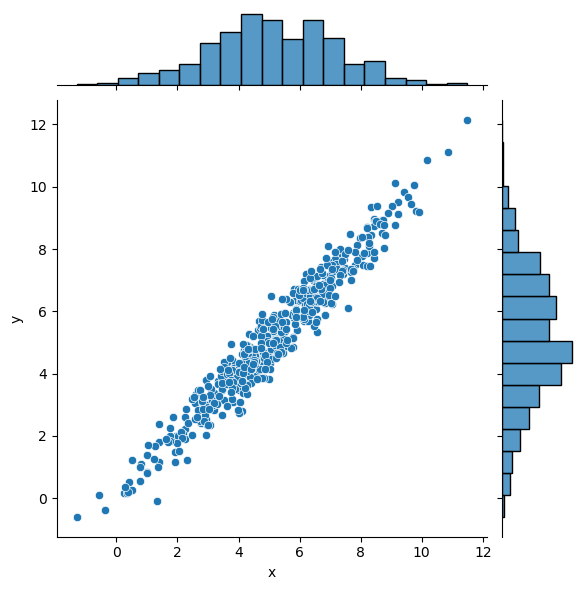

In [7]:
sns.jointplot(x="x", y="y", data=pd.DataFrame({"x":x,"y":y}));

**Wykres gęstościowy i jądrowe estymatory rozkładów brzegowych**

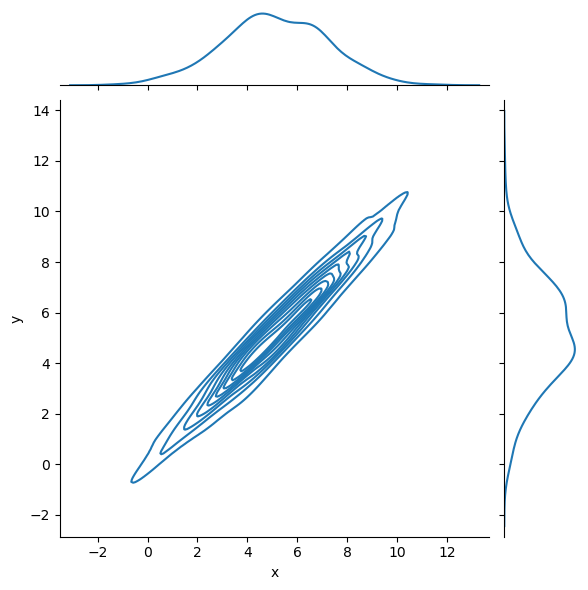

In [8]:
sns.jointplot(x="x", y="y", data=pd.DataFrame({"x":x,"y":y}), kind="kde");

**Wykres gęstościowy i jądrowe estymatory rozkładów brzegowych + wykres rozrzutu**

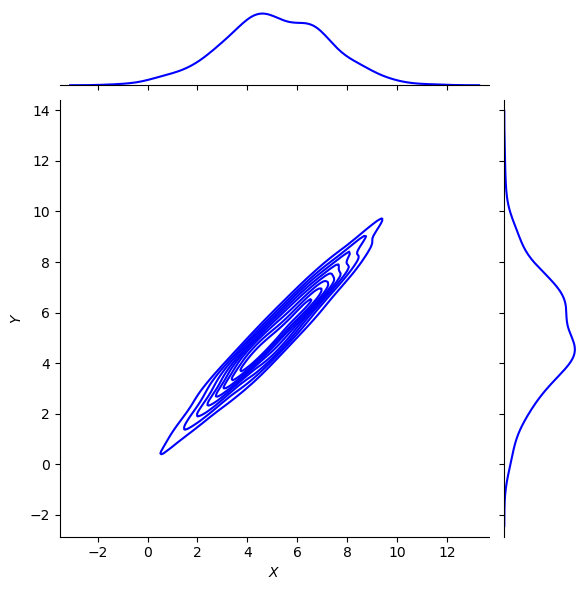

In [9]:
g = sns.jointplot(x="x", y="y", data=pd.DataFrame({"x":x,"y":y}), kind="kde", color="b")
g.plot_joint(plt.scatter, c="w", s=30, linewidth=1, marker="+")
g.ax_joint.collections[0].set_alpha(0)
g.set_axis_labels("$X$", "$Y$");

**Histogramy oraz wykresy rozrzutu tzw. pairplot**

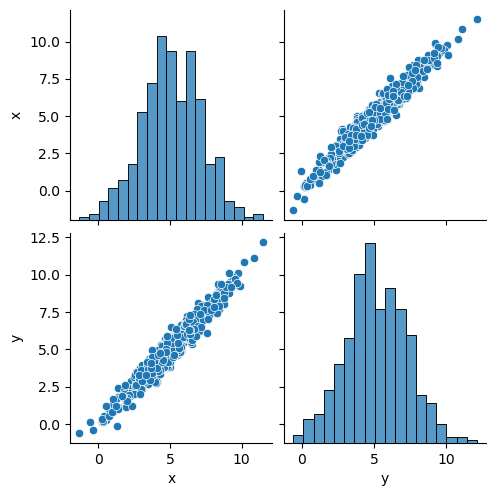

In [10]:
sns.pairplot(pd.DataFrame({"x":x,"y":y}));